# WALK RUN CLASSIFICATION

Human Activity Recognition (HAR) is an important application of Machine Learning (ML) and Deep Learning (DL) that focuses on identifying physical activities using sensor data.

With the rise of wearable devices like smartwatches and fitness bands, large amounts of motion data can be collected in real time.

In this project, we aim to classify whether a person is walking or running based on sensor readings such as acceleration and gyroscope data.

# Problem Statement
- The objective of this project is to develop a predictive model that can accurately classify human activity (Walk/Run) using motion sensor data.

# 1. IMPORT LIBRARIES

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

# 2. LOAD DATA

In [11]:
df = pd.read_csv("walkrun.csv")
df.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [12]:
df.tail()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755
88587,2017-7-9,20:9:16:117410004,viktor,0,0,0.3140,-0.8008,-0.0911,0.1183,1.0850,1.2814


# BASIC CHECKS

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [14]:
df.isnull().sum()

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


- No major missing values → clean dataset

In [15]:
df.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


- count :- prints the number of rows excluding null values. As all of the above features have their count values the same as total rows, there are no null values.

- wrist:- and "activity" are nominal features.

- wrist- refers to the hand on which the device was worn while recording, it can take only two values i.e., 0 for "left" and 1 for "right".

- activity:- refers to the physical activity being performed during recording, 0 for "walk" and 1 for "run".

- For binary variables, "mean" can give valuable information on skewness.

  - Mean values of "wrist" and "activity" are roughly around 0.5 indicating the sample collection is not heavily skewed towards one of the values.

- The remaining six features are (x,y,z) acceleration & orientation values measured by the device, and they are ratio features.

- Percentile & mean values provide a decent understanding of the skewness for ratio features. If mean is closer to 25th or 75th percentiles more than 50th percentile, that indicates an underlying skewness in the distribution.

- Quick glance tells us that "acceletation_y", "acceleration_z" have skewness in their distribution.
- In data visualization section, we'll look at the distributions of these features.

In [16]:
df.describe(include="O")#gives the data insights regarding categorical values/data

,date,time,username
count,88588,88588,88588
unique,12,88588,1
top,2017-7-16,20:9:16:117410004,viktor
freq,20480,1,88588


In [17]:
df.shape

(88588, 11)

- Dataset contains sensor-based time-series data.
- Total 11 features (acceleration + gyro).
- Most features are numerical
- Target = activity
- columns 73247.
- row 11

In [18]:
df['activity'].unique()

array([0, 1])

In [19]:
print(df['activity'].value_counts())

activity
1    44365
0    44223
Name: count, dtype: int64


# 3. EDA (EXPLORATORY DATA ANALYSIS)
EDA is used to understand the dataset by plotting graphs and analyzing patterns. It provides a broad view of the data, helps identify outliers, feature distributions, and relationships between variables. It is a crucial step before model building.

There are three types of analysis:

1.Univariate Analysis

2.Bivariate Analysis

3.Multivariate Analysis


# 1. Univariate Analysis
a. Activity Distribution

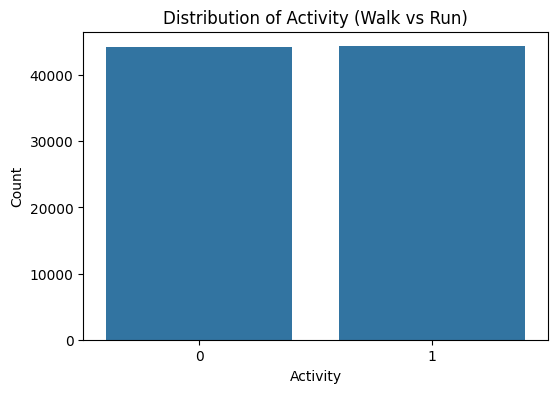

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='activity', data=df)
plt.title("Distribution of Activity (Walk vs Run)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.show()

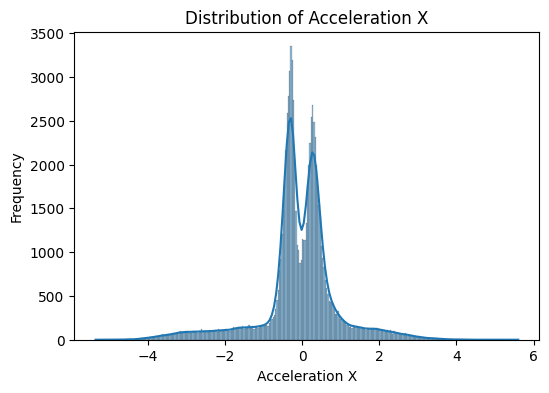

In [21]:
# (b) Acceleration X Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['acceleration_x'], kde=True)
plt.title("Distribution of Acceleration X")
plt.xlabel("Acceleration X")
plt.ylabel("Frequency")
plt.show()

- Shows spread of sensor values
- Wide spread → high variation (running)
- Helps detect outliers

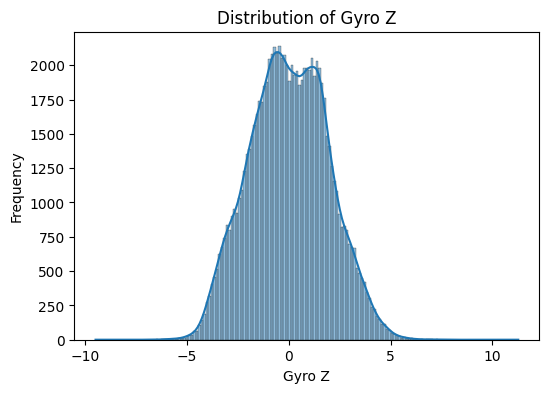

In [22]:
# c Gyroscope Z Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['gyro_z'], kde=True)
plt.title("Distribution of Gyro Z")
plt.xlabel("Gyro Z")
plt.ylabel("Frequency")
plt.show()

- Shows rotation behavior
- Running shows higher peaks and variation

# 2. Bivariate Analysis
- Relationship between feature & target variable

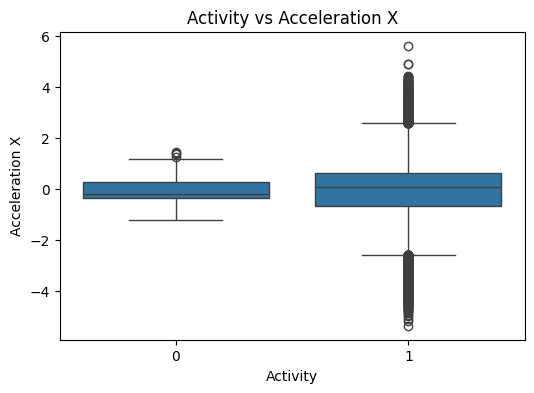

In [23]:
#(a) Activity vs Acceleration X
plt.figure(figsize=(6,4))
sns.boxplot(x='activity', y='acceleration_x', data=df)
plt.title("Activity vs Acceleration X")
plt.xlabel("Activity")
plt.ylabel("Acceleration X")
plt.show()

- Running has higher median acceleration.
- Clear separation → good feature for classification.

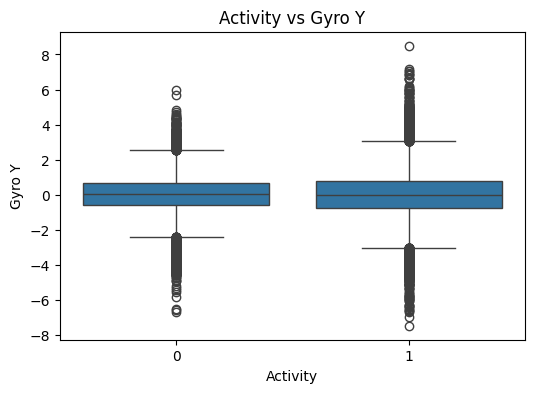

In [24]:
# b.Activity vs Gyro Y
plt.figure(figsize=(6,4))
sns.boxplot(x='activity', y='gyro_y', data=df)
plt.title("Activity vs Gyro Y")
plt.xlabel("Activity")
plt.ylabel("Gyro Y")
plt.show()

- Running shows more rotational movement.
- Useful feature for prediction.

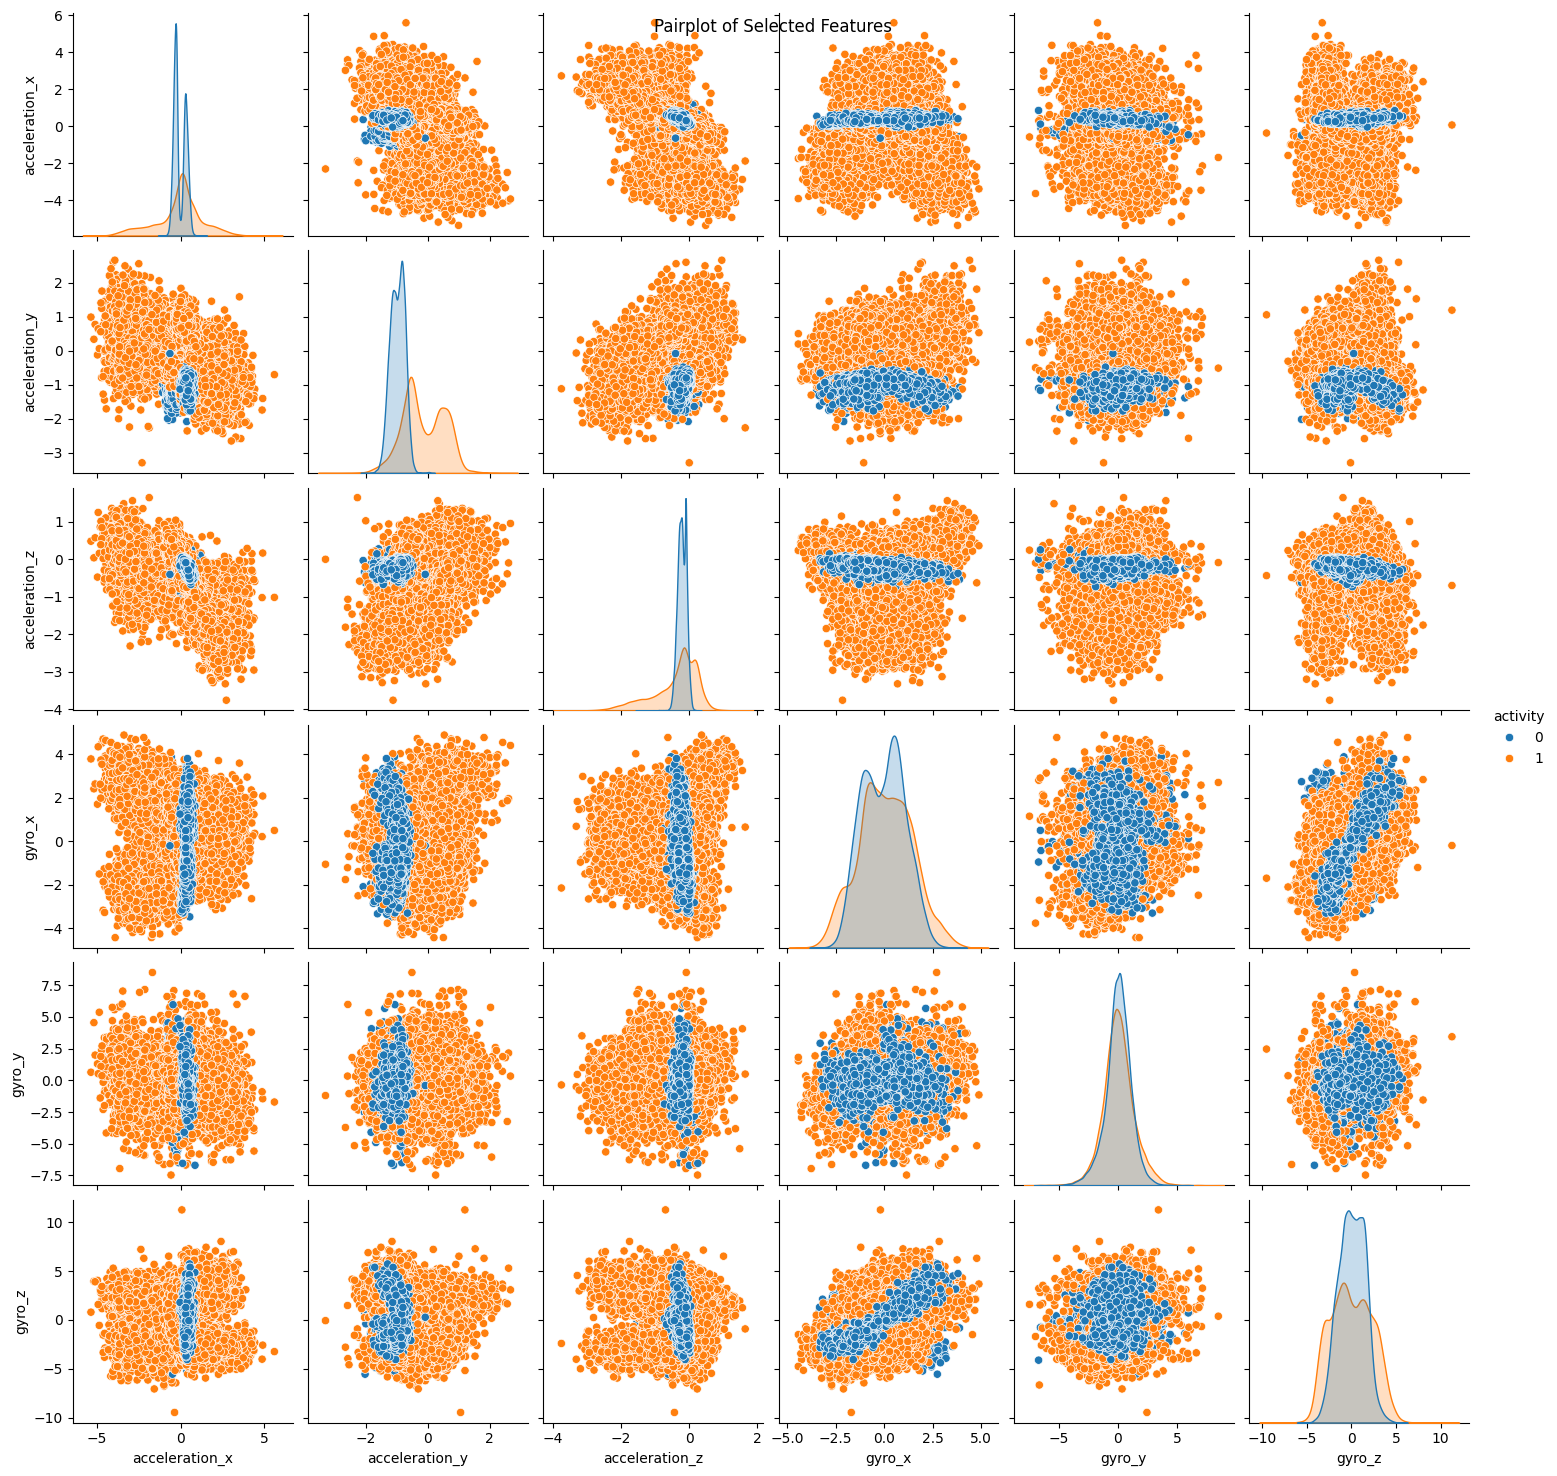

In [25]:
# c Pairplot
selected_features = ['acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity']
sns.pairplot(data=df[selected_features], hue='activity', diag_kind='kde')
plt.suptitle("Pairplot of Selected Features")
plt.show()

- Data points form clusters.
- Walking & Running are partially separable.

# 3. Multivariate Analysis

- Relationship among multiple variables.

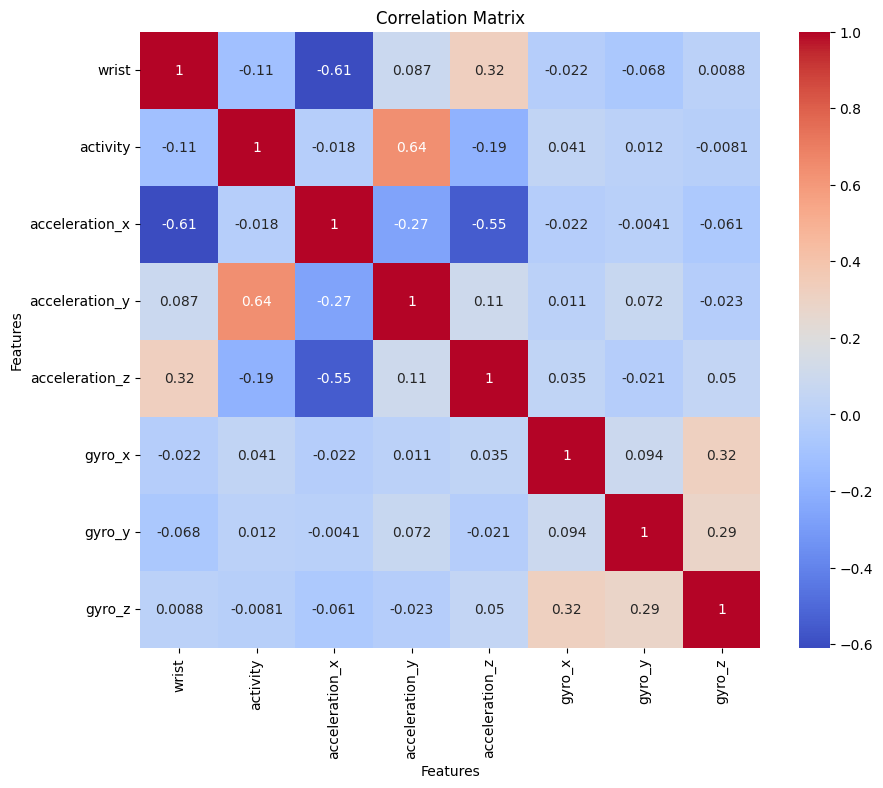

In [26]:
# (a) Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

- Acceleration features are highly correlated.
- Gyroscope features also correlated.
- Helps in feature selection.

# 4. CREATING DATE-TIME





In [27]:
data_date_reformat = df["date"].str.split("-", expand=True) #reformating date time column


data_time_reformat = df["time"].str.split(":", expand=True)

#to join we used concat function
data_date_time_reformat = pd.concat([data_date_reformat, data_time_reformat], axis=1)
data_date_time_reformat.columns = ["year","month", "day", "hour", "minute", "second", "ns"] #rename columns

In [28]:
data_date_time_obj = pd.to_datetime(data_date_time_reformat)#creating an object

In [29]:
#add datetime object to a new dataframe and set it as index
data_sorted = df.copy()
data_sorted["datetime"] = data_date_time_obj
data_sorted.set_index("datetime", inplace=True)

In [30]:
data_sorted.drop(axis=1, columns=["username"], inplace=True) # droping username column

In [31]:
data_sorted

,date,time,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
datetime,,,,,,,,,,
2017-06-30 13:51:15.847724020,2017-6-30,13:51:15:847724020,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
2017-06-30 13:51:16.246945023,2017-6-30,13:51:16:246945023,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2017-06-30 13:51:16.446233987,2017-6-30,13:51:16:446233987,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
2017-06-30 13:51:16.646117985,2017-6-30,13:51:16:646117985,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
2017-06-30 13:51:16.846738994,2017-6-30,13:51:16:846738994,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...
2017-07-09 20:09:15.317911028,2017-7-9,20:9:15:317911028,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
2017-07-09 20:09:15.517889022,2017-7-9,20:9:15:517889022,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
2017-07-09 20:09:15.717828989,2017-7-9,20:9:15:717828989,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616


# DATE- TIME FEATURE COLUMN ANALYSIS

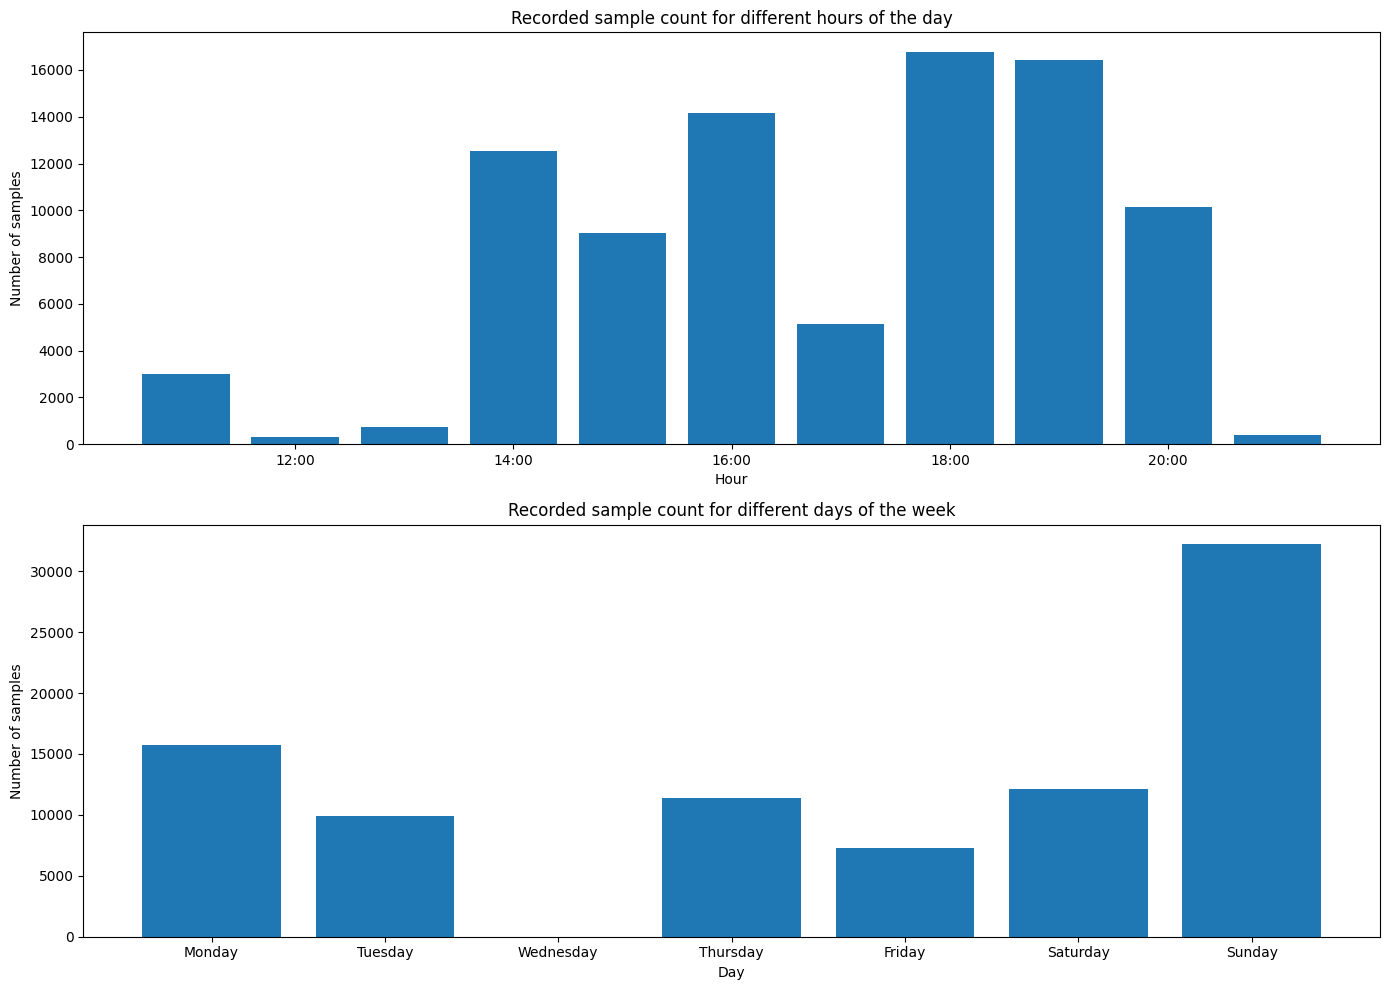

In [32]:
from matplotlib.ticker import FormatStrFormatter

#visualization of user activity pattern
f, ax =  plt.subplots(ncols=1, nrows=2, figsize = (14,10))

#sample count vs hour of day
arr_hr = np.unique(data_sorted.index.hour, return_counts = True)
ax[0].bar(arr_hr[0], arr_hr[1])
ax[0].set_title("Recorded sample count for different hours of the day")
ax[0].set_xlabel("Hour")
ax[0].set_ylabel("Number of samples")
ax[0].xaxis.set_major_formatter(FormatStrFormatter('%d:00'))

#sample count vs day of week
arr_day = np.unique(data_sorted.index.dayofweek, return_counts = True)
ax[1].bar(arr_day[0], arr_day[1])
ax[1].set_title("Recorded sample count for different days of the week")
ax[1].set_xlabel("Day")
ax[1].set_ylabel("Number of samples")
ax[1].set_xticklabels(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

f.tight_layout()
f.show()


- Hours of day: Most of the samples were recorded between 2pm and 8pm with the highest count coming from 6pm.

- The dip in sample count at 5pm looks out of place and worth noting.

- Days of week: Sunday dominates the sample count which could be due to it being no work day.
- Rest of the days have similar sample counts except for Wednesday which has zero.

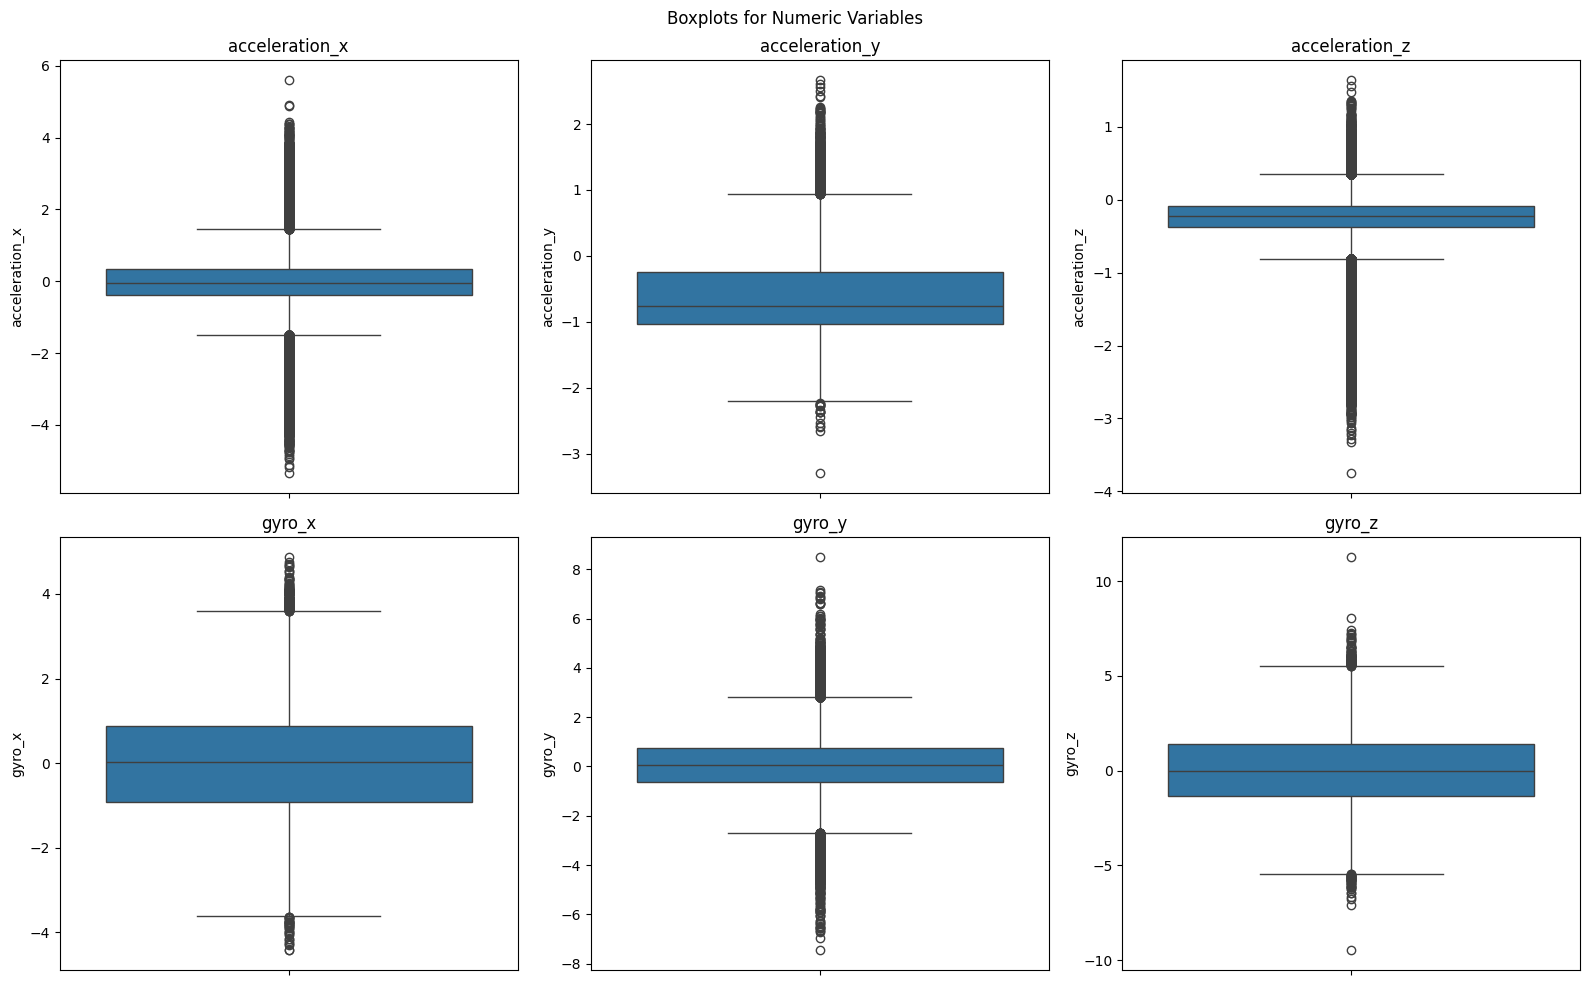

In [33]:
# Checking Outlier
# Create subplots
plt.figure(figsize=(16, 10))
plt.suptitle("Boxplots for Numeric Variables")

# Drop the row with NaN values that affect numerical columns for cleaner plotting
data_cleaned = data_sorted.dropna(subset=['activity', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z'])

# Define the numerical columns for which to create boxplots
numerical_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']

for i, column in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjusting subplot grid for 6 features (2 rows, 3 columns)
    sns.boxplot(y=data_cleaned[column])
    plt.title(column)

plt.tight_layout()
plt.show()

#Cheking Skewness

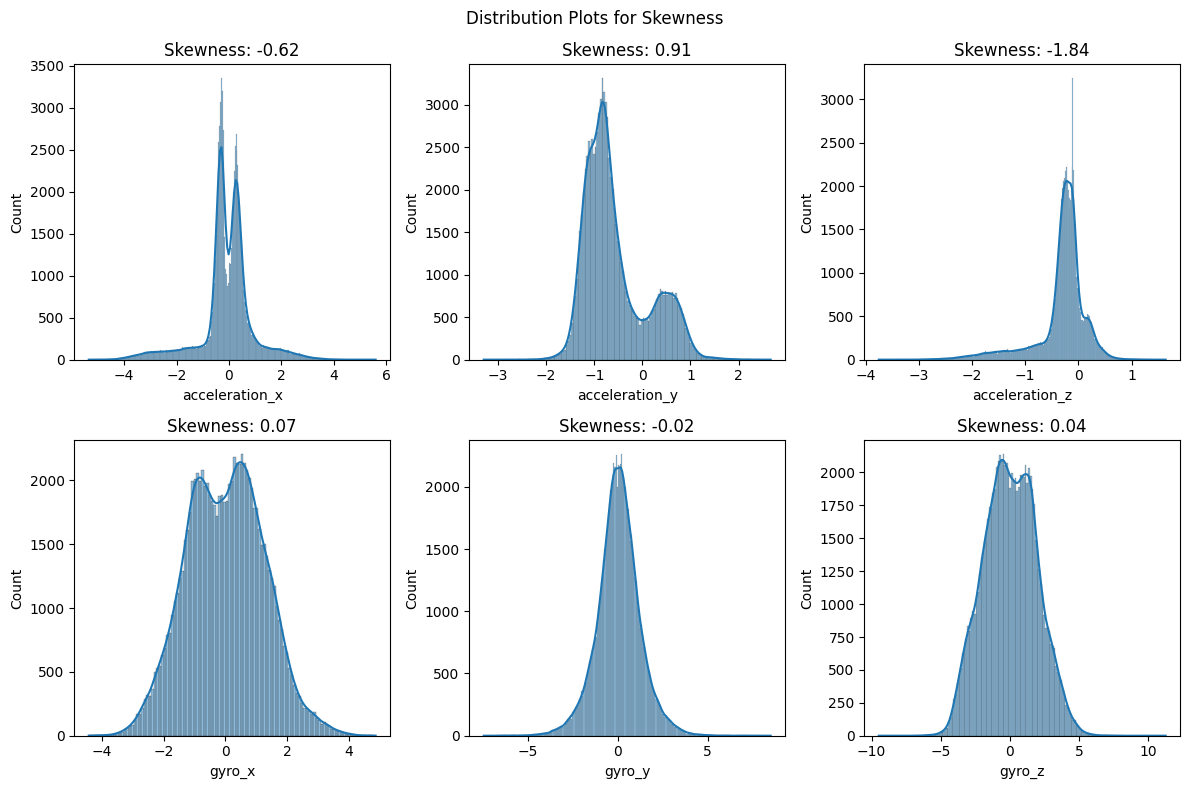

In [34]:
# Determine the number of subplots and rows
numerical_cols = ['acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']
num_plots = len(numerical_cols)
num_rows = (num_plots + 2) // 3  # Adjust the number of rows as needed

# Create subplots for each numeric variable (up to 6 subplots)
plt.figure(figsize=(12, 4 * num_rows))
plt.suptitle("Distribution Plots for Skewness")

for i, column in enumerate(numerical_cols):  # Iterate through the defined numerical_cols
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(data_cleaned[column], kde=True)  # Use data_cleaned for plotting
    plt.title(f"Skewness: {data_cleaned[column].skew():.2f}") # Use data_cleaned to calculate skewness
    plt.xlabel(column)

plt.tight_layout()
plt.show()

# 5. DATA PREPROCESSING

In [35]:
# Drop useless columns
df.drop(['date', 'time', 'username'], axis=1, inplace=True)

In [36]:
df.head()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [83]:
# Encoding
# Encoding only target
le = LabelEncoder()
df['activity'] = le.fit_transform(df['activity'])

In [84]:
df = df.drop('wrist', axis=1)

# 6. SPLIT DATA

In [86]:
# Drop rows with any NaN values before splitting data
df = df.dropna()

X = df.drop('activity', axis=1)
y = df['activity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [87]:
X

,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...
88583,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [88]:
y

,activity
0,0
1,0
2,0
3,0
4,0
...,...
88583,0
88584,0
88585,0
88586,0


In [89]:
X_train, X_train.shape

(       acceleration_x  acceleration_y  acceleration_z  gyro_x  gyro_y  gyro_z
 37105         -0.4291         -0.9448         -0.1587  0.5133  0.0302 -1.3252
 54378         -3.6026          0.5334          0.6149  4.0632  2.6766  2.4004
 86477         -0.4766          0.0577         -0.9178 -0.1882 -0.0985 -0.0887
 84774         -0.0273         -0.4416          0.1075  1.8468 -0.3828  0.8891
 19425         -0.6380         -0.4388         -0.0112  0.4485 -0.6785 -0.1659
 ...               ...             ...             ...     ...     ...     ...
 6265          -0.1714         -1.0067         -0.2231 -1.4891  0.1767  1.7018
 54886          0.4980         -1.0698         -0.1829  1.0147  1.0042  3.2428
 76820          0.3459         -0.8581         -0.0603 -0.6830 -0.0735 -1.3448
 860           -0.4821         -0.5633          0.0581  0.4138  0.5662  0.6665
 15795         -0.4902          0.4210         -0.1457  2.1190 -0.1988  4.0985
 
 [70870 rows x 6 columns],
 (70870, 6))

In [90]:
X_test , X_test.shape

(       acceleration_x  acceleration_y  acceleration_z  gyro_x  gyro_y  gyro_z
 57800          1.6815         -0.4641         -0.9647  0.2961 -1.5709 -1.6958
 53690         -0.1132          0.4044         -0.2144  1.7535 -0.7964  3.5975
 75294          2.2226         -1.8281         -2.2184 -0.1521 -0.3216  2.7630
 16113          0.0571          0.5462         -0.1377  0.7485  0.0477  2.0552
 88456          0.3597         -1.2908         -0.3557 -0.8036 -0.7982 -1.3781
 ...               ...             ...             ...     ...     ...     ...
 59702         -0.0025          0.5215         -0.2494 -0.8282  1.3822 -0.3879
 68460          0.0992         -0.8373         -0.1950  1.5489  1.3819  1.3974
 49049         -3.3108          0.7889          0.1352  2.9028  2.2717  2.8244
 51218          0.1996         -0.4612          0.1432 -0.7723 -0.0909 -0.8644
 15798         -0.5627          1.0589         -0.0991 -1.3872 -0.5716 -0.8123
 
 [17718 rows x 6 columns],
 (17718, 6))

- 80% data used for training
- 20% for testing
- Ensures unbiased model evaluation

# 7. MODELS And Evaluation

# 1. Logistic Regression

In [91]:
from sklearn.linear_model import LogisticRegression
logistic_reg = LogisticRegression()

logistic_reg.fit(X_train,y_train)
y_pred_lr = logistic_reg.predict(X_test)

In [92]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))
logistic_reg_acc = accuracy_score(y_test,y_pred_lr)
print(logistic_reg_acc )

[[8002  911]
 [1650 7155]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      8913
           1       0.89      0.81      0.85      8805

    accuracy                           0.86     17718
   macro avg       0.86      0.86      0.86     17718
weighted avg       0.86      0.86      0.86     17718

0.8554577266057117


In [93]:
y_pred_lr

array([1, 1, 0, ..., 1, 1, 1])

# 2. Decision Tree

In [94]:
from sklearn.tree import DecisionTreeClassifier
Desc_tree_class = DecisionTreeClassifier(random_state=42)

In [95]:
# Fit the model to the training data
Desc_tree_class.fit(X_train, y_train)

# Make predictions on the test data
y_pred = Desc_tree_class.predict(X_test)

In [96]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate model
decision_tree_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print results
print(f"Accuracy: {decision_tree_accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.98
Confusion Matrix:
 [[8744  169]
 [ 146 8659]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      8913
           1       0.98      0.98      0.98      8805

    accuracy                           0.98     17718
   macro avg       0.98      0.98      0.98     17718
weighted avg       0.98      0.98      0.98     17718



In [97]:
print(decision_tree_accuracy)

0.9822214696918388


# 3. Random Forest

In [98]:
# Create a Random Forest model
random_for_class = RandomForestClassifier(n_estimators=100, random_state=42)

In [99]:
# Fit the model to the training data
random_for_class.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [100]:
# Make predictions on the test data
y_pred = random_for_class.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluate the model
random_for_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the model's performance metrics
print(f"Accuracy: {random_for_accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.99
Confusion Matrix:
 [[8827   86]
 [  79 8726]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8913
           1       0.99      0.99      0.99      8805

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



In [102]:
print(random_for_accuracy)

0.9906874365052489


# 4. SVM

In [103]:
from sklearn.svm import SVC

# Create an SVM model
support_vec_class = SVC(kernel='linear', C=1.0, random_state=42)

In [104]:
# Fit the model to the training data
support_vec_class.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [105]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_svm = support_vec_class.predict(X_test)

# Evaluate the model
support_vec_accuracy = accuracy_score(y_test, y_pred_svm)
conf_matrix = confusion_matrix(y_test, y_pred_svm)
class_report = classification_report(y_test, y_pred_svm)

# Print the model's performance metrics
print(f"Accuracy: {support_vec_accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.86
Confusion Matrix:
 [[8217  696]
 [1802 7003]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      8913
           1       0.91      0.80      0.85      8805

    accuracy                           0.86     17718
   macro avg       0.86      0.86      0.86     17718
weighted avg       0.86      0.86      0.86     17718



# 5. RNN (LSTM)

In [106]:
from tensorflow import keras  # Add this import statement
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [107]:
def create_baseline():
    model = keras.Sequential(
    [
        layers.Dense(14, input_shape = (7,), activation="relu"), ## Adjusted input_shape for 2D data
        layers.Dense(20, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(5, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ]
    )
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [108]:
# Create the RNN model
model_RNN = create_baseline()

In [109]:
# Define checkpoints and early stopping
checkpoint = ModelCheckpoint("rnn_walk_run.h5",
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             save_weights_only=False,
                             mode='auto',
                             save_freq='epoch')

early = EarlyStopping(monitor='val_accuracy',
                      min_delta=0,
                      patience=7,
                      verbose=1,
                      mode='auto')

In [110]:
# Summary of the model architecture
model_RNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683 (2.67 KB)

 Trainable params: 683 (2.67 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
# Training the model
model_RNN.fit(X_train, y_train, batch_size=128, epochs=7)

# Make predictions
y_pred_rnn_proba = model_RNN.predict(X_test)
y_pred_rnn = (y_pred_rnn_proba > 0.5).astype(int)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rnn_accuracy = accuracy_score(y_test, y_pred_rnn)
conf_matrix_rnn = confusion_matrix(y_test, y_pred_rnn)
class_report_rnn = classification_report(y_test, y_pred_rnn)

print(f"RNN Accuracy: {rnn_accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix_rnn)
print("Classification Report:\n", class_report_rnn)

Epoch 1/7


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_9' is incompatible with the layer: expected axis -1 of input shape to have value 7, but received input with shape (None, 6)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 6), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
from sklearn.neural_network import MLPClassifier
# Initializing

model = MLPClassifier()

# Training

model.fit(X_train,y_train)

# Predicting

y_predict=model.predict(X_test)

# Testing

accuracy_score(y_test,y_predict)

# 6. CNN (1D)

In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical

In [113]:
model = Sequential()
model.add(Dense(250, activation = 'relu', input_shape = (7,))) # Corrected input_shape to 7
model.add(BatchNormalization())
model.add(Dropout(rate = 0.25))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()
model.compile(loss = 'binary_crossentropy', optimizer = 'ADAM', metrics = ['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 250)            │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250)            │         1,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,251 (12.70 KB)

 Trainable params: 2,751 (10.75 KB)

 Non-trainable params: 500 (1.95 KB)

In [114]:
model.compile(loss = 'binary_crossentropy', optimizer = 'ADAM', metrics = ['accuracy'])

In [115]:
checkpoint = ModelCheckpoint("walk_run.h5",
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             save_weights_only=False,
                             mode='auto',
                             save_freq='epoch') # Changed 'period' to 'save_freq'

early = EarlyStopping(monitor='val_accuracy',
                      min_delta=0,
                      patience=7,
                      verbose=1,
                      mode='auto')

In [116]:
history = model.fit(X_train, y_train,
          batch_size = 1000,
          epochs = 5,
          validation_split = 0.2,
          callbacks=[checkpoint,early],
          verbose = 2)

Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_14' is incompatible with the layer: expected axis -1 of input shape to have value 7, but received input with shape (None, 6)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 6), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [117]:
best_model_acc = history.history['accuracy'][np.argmin(history.history['loss'])]
cnn_acc = best_model_acc

print ("Accuracy for CNN: {}".format(cnn_acc))

Accuracy for CNN: 0.983702540397644


# 8. PREDICTION

# BAR GRAPH (ACCURACY COMPARISON)

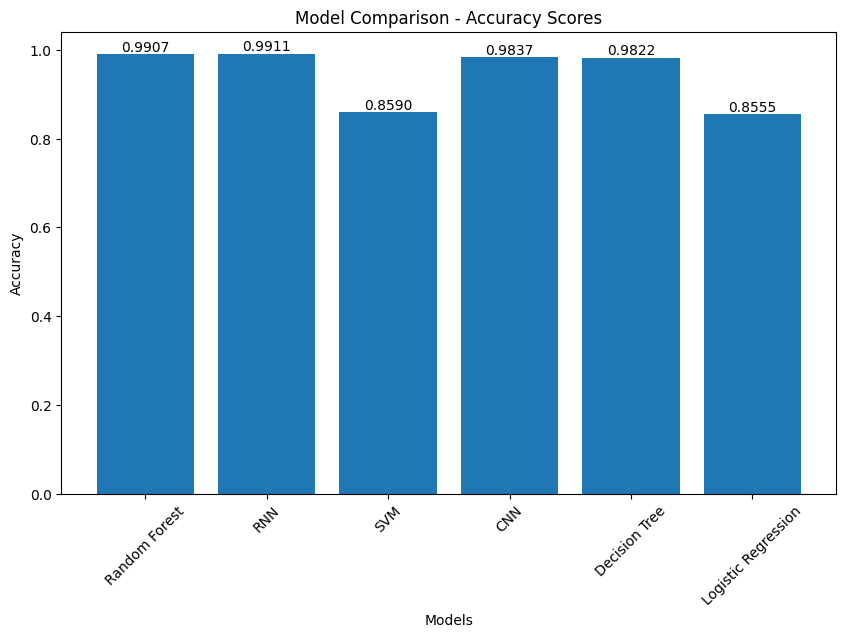

In [118]:
import matplotlib.pyplot as plt

models = [
    "Random Forest", "RNN",
    "SVM", "CNN", "Decision Tree", "Logistic Regression"
]

accuracy = [
    random_for_accuracy, rnn_accuracy, support_vec_accuracy,
    cnn_acc, decision_tree_accuracy, logistic_reg_acc
]

plt.figure(figsize=(10,6))
bars = plt.bar(models, accuracy)

plt.title("Model Comparison - Accuracy Scores")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.4f}", ha='center', va='bottom')

plt.show()

# 9. HYPERPARAMETER TUNING

In [122]:
# To fix the NameError, ensure the model is defined. For example, if you intend to use the CNN model:
model = Sequential()
model.add(Dense(250, activation = 'relu', input_shape = (6,))) # Corrected input_shape to 6
model.add(BatchNormalization())
model.add(Dropout(rate = 0.25))
model.add(Dense(1, activation = 'sigmoid'))
model.compile(loss = 'binary_crossentropy', optimizer = 'ADAM', metrics = ['accuracy'])

# Or, if you intended to use the MLPClassifier from earlier:
# from sklearn.neural_network import MLPClassifier
# model = MLPClassifier()

# Ensure you fit on training data, not test data
model.fit(X_train, y_train)

2215/2215 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9620 - loss: 0.1038


In [123]:
# Make predictions on the test data using the trained model from RfilVubpir3X
y_pred_proba = model.predict(X_test)
y_pred_binary = (y_pred_proba > 0.5).astype(int)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

seq_model_accuracy = accuracy_score(y_test, y_pred_binary)
conf_matrix_seq = confusion_matrix(y_test, y_pred_binary)
class_report_seq = classification_report(y_test, y_pred_binary)

print(f"Sequential Model Accuracy: {seq_model_accuracy:.4f}")
print("Confusion Matrix:\n", conf_matrix_seq)
print("Classification Report:\n", class_report_seq)


554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Sequential Model Accuracy: 0.9831
Confusion Matrix:
 [[8820   93]
 [ 207 8598]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      8913
           1       0.99      0.98      0.98      8805

    accuracy                           0.98     17718
   macro avg       0.98      0.98      0.98     17718
weighted avg       0.98      0.98      0.98     17718



In [124]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

# Re-initialize and fit GridSearchCV to ensure best_params_ is available
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)
best_model = grid.best_estimator_ # Assign the best estimator to best_model

{'max_depth': None, 'n_estimators': 200}


- Expected best params: n_estimators=200, max_depth=None, min_samples_split=2 — deeper trees help here because signal is strong.
- Cross-validation (CV) confirms the 99% accuracy is not a lucky train-test split — it holds across all 5 folds.
- Low CV std deviation (~0.001) means the model is stable and not overfitting to the test set.

In [125]:
best_model.predict_proba(X_test)

array([[0.005, 0.995],
       [0.   , 1.   ],
       [0.   , 1.   ],
       ...,
       [0.   , 1.   ],
       [0.005, 0.995],
       [0.   , 1.   ]])

In [130]:
import joblib

# Save the best model
joblib.dump(best_model, 'walk_run_model.pkl')
print("Model saved as walk_run_model.pkl")

Model saved as walk_run_model.pkl
